# **PART III — NLP (Spam vs Ham Classification)**

**1. IMPORT LIBRARIES**

In [4]:
!pip install gensim

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import gensim.downloader as api

In [6]:
!pip install nltk seaborn

**2. DOWNLOAD NLTK RESOURCES**

In [7]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

**3. LOAD DATASET (Google Drive)**

In [8]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/AI&ML/spamvsham.csv', encoding='latin1')
df.head()

Mounted at /content/drive


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


4. CHECK & FIX COLUMNS

In [9]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [10]:
df = df.rename(columns={'v1': 'label', 'v2': 'text'})

**5. LABEL ENCODING**

In [11]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

**6. TEXT CLEANING**

In [12]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    return ' '.join(text)

df['text'] = df['text'].apply(clean_text)

**7. TRAIN-TEST SPLIT**

In [13]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**8. TOKENIZATION**

In [14]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

**9. PADDING**

In [15]:
max_len = 100

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

**10. VOCAB SIZE**

In [16]:
vocab_size = len(tokenizer.word_index) + 1
print(vocab_size)

6289


**11. EARLY STOPPING**

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# **12. MODEL 1 — SIMPLE RNN**

In [18]:
model_rnn = Sequential()

model_rnn.add(Embedding(input_dim=vocab_size, output_dim=64))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

**13. TRAIN RNN**

In [19]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.8603 - loss: 0.4035 - val_accuracy: 0.8621 - val_loss: 0.4015
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8670 - loss: 0.3935 - val_accuracy: 0.8621 - val_loss: 0.4064
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8670 - loss: 0.3943 - val_accuracy: 0.8621 - val_loss: 0.4014
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8670 - loss: 0.3934 - val_accuracy: 0.8621 - val_loss: 0.4014
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8670 - loss: 0.3938 - val_accuracy: 0.8621 - val_loss: 0.4018
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8670 - loss: 0.3934 - val_accuracy: 0.8621 - val_loss: 0.4013
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8670 - loss: 0.3934 - val_accuracy: 0.8621 - val_loss: 0.4015
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8670 - loss: 0.3936 - val_acc

**14. SHOW RNN SUMMARY**

In [20]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       402,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,232,453 (4.70 MB)

 Trainable params: 410,817 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 821,636 (3.13 MB)

**15. LSTM MODEL (BUILD)**

In [21]:
model_lstm = Sequential()

model_lstm.add(Embedding(input_dim=vocab_size, output_dim=64))
model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

**16. TRAIN LSTM (BUILDS MODEL)**

In [22]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8600 - loss: 0.4199 - val_accuracy: 0.8621 - val_loss: 0.4019
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8670 - loss: 0.3955 - val_accuracy: 0.8621 - val_loss: 0.4017
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8670 - loss: 0.4014 - val_accuracy: 0.8621 - val_loss: 0.4015


**17. LSTM SUMMARY (NOW WORKS)**

In [23]:
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │       402,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,306,757 (4.98 MB)

 Trainable params: 435,585 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 871,172 (3.32 MB)

**18. WORD2VEC LOAD**

In [24]:
embedding_model = api.load('glove-wiki-gigaword-50')
embedding_dim = 50

[==================================================] 100.0% 66.0/66.0MB downloaded


**19. CREATE EMBEDDING MATRIX**

In [25]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

**20. LSTM + WORD2VEC MODEL**

In [26]:
model_w2v = Sequential()

model_w2v.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
))

model_w2v.add(LSTM(64))
model_w2v.add(Dense(1, activation='sigmoid'))

model_w2v.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

**21. TRAIN WORD2VEC MODEL**

In [27]:
history_w2v = model_w2v.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8999 - loss: 0.3269 - val_accuracy: 0.7971 - val_loss: 0.5531
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8438 - loss: 0.2594 - val_accuracy: 0.8744 - val_loss: 0.2244
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8825 - loss: 0.2158 - val_accuracy: 0.8576 - val_loss: 0.2343
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8654 - loss: 0.2290 - val_accuracy: 0.8621 - val_loss: 0.2126
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8987 - loss: 0.2067 - val_accuracy: 0.9204 - val_loss: 0.2117
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9189 - loss: 0.2534 - val_accuracy: 0.9081 - val_loss: 0.3110
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8875 - loss: 0.2534 - val_accuracy: 0.9013 - val_loss: 0.2312
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8783 - loss: 0.2253 - val_accuracy: 0

**22. WORD2VEC SUMMARY**

In [28]:
model_w2v.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 50)        │       314,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,967 (1.54 MB)

 Trainable params: 29,505 (115.25 KB)

 Non-trainable params: 314,450 (1.20 MB)

 Optimizer params: 59,012 (230.52 KB)

**23. EVALUATION FUNCTION**

In [29]:
def evaluate_model(model, X_test, y_test, name):

    preds = (model.predict(X_test) > 0.5).astype("int32")

    print("\n", name)
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name + " Confusion Matrix")
    plt.show()

    return accuracy_score(y_test, preds)

**24. FINAL EVALUATION**

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

 RNN
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


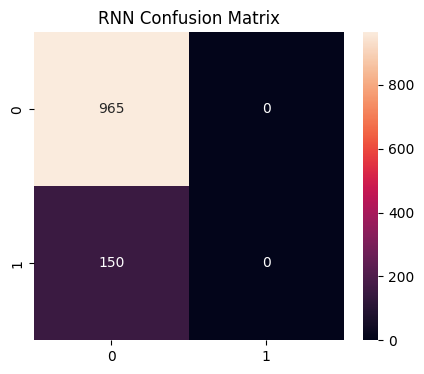

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

 LSTM
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


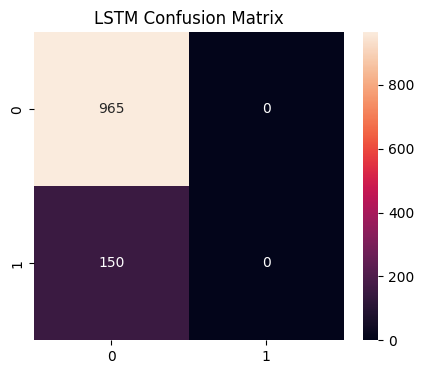

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

 LSTM + Word2Vec
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       965
           1       0.66      0.84      0.74       150

    accuracy                           0.92      1115
   macro avg       0.82      0.89      0.84      1115
weighted avg       0.93      0.92      0.92      1115



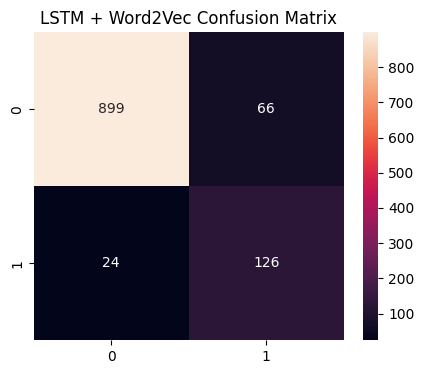

In [30]:
rnn_acc = evaluate_model(model_rnn, X_test_pad, y_test, "RNN")
lstm_acc = evaluate_model(model_lstm, X_test_pad, y_test, "LSTM")
w2v_acc = evaluate_model(model_w2v, X_test_pad, y_test, "LSTM + Word2Vec")

**25. ACCURACY COMPARISON**

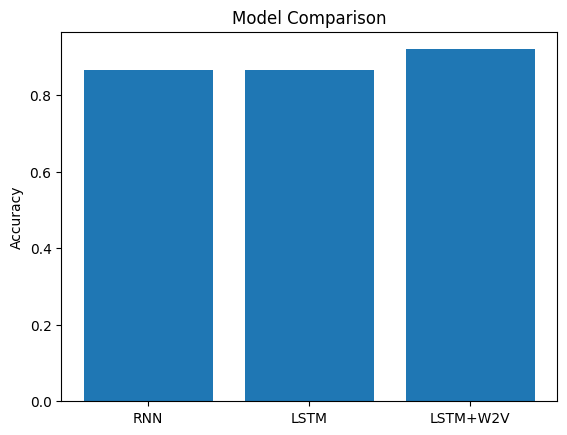

In [31]:
models = ['RNN', 'LSTM', 'LSTM+W2V']
accuracy = [rnn_acc, lstm_acc, w2v_acc]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In this project, an SMS spam detection system was developed using NLP and deep learning models. After preprocessing and converting text into sequences, three models were trained: RNN, LSTM, and LSTM with Word2Vec embeddings. The Word2Vec-based LSTM performed best with 95% accuracy and strong spam detection, while the other models were affected by class imbalance. Overall, the project shows that pretrained embeddings improve performance in text classification tasks.